<a href="https://colab.research.google.com/github/Ayushkr77/datascience-ai-ml/blob/main/PHASE%202%20%E2%80%94%20Statistical%20Thinking%20%2B%20Data%20Analysis%20/%20Notebooks%20/%20Probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-On Practice

You are given a dataset of employees and students with the following columns:

- study_hours  
- exam_score  
- pass (True/False)  
- experience  
- department (IT, HR, Finance)  
- city (Bangalore, Delhi, Mumbai)  
- salary  
- high_salary (True/False)  

---

## 🔹 Your Tasks

### Part A — Basic Probability

- What is the probability that a student passes the exam?  
- What is the probability that a student scores more than 80?  

---

### Part B — Conditional Probability

- What is the probability of passing given study hours > 5?  
- Does studying more increase the chances of passing?  

---

### Part C — Salary Analysis

- What is the probability of high salary?  
- What is the probability of high salary for each department?  
- What is the probability of high salary given experience > 5?  
- Compare average salary across cities.  

---

### Part D — Distribution Analysis

- Plot the distribution of exam scores. Is it normal or skewed?  
- Plot the salary distribution. Is it normal or skewed?  
- Calculate skewness of salary.  
- Compare mean vs median salary.  

---

### Part E — Insight Writing (Most Important)

- Write at least 3 meaningful insights from the analysis.  

In [1]:
# Step 1: Create Dataset

import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

df = pd.DataFrame({
    "study_hours": np.random.randint(1, 10, n),  # Random integers between 1 and 9, and will create n(200) rows.
    "department": np.random.choice(["IT", "HR", "Finance"], n),
    "city": np.random.choice(["Bangalore", "Delhi", "Mumbai"], n),
    "experience": np.random.randint(0, 10, n)
})

df["exam_score"] = df["study_hours"] * 10 + np.random.normal(0, 10, n)   # np.random.normal(mean, std_dev, size). here it means Most values will be near 0, many will fall between -10 and +10, some can go beyond that (like 15, -20, etc.)
df["pass"] = df["exam_score"] >= 50

df["salary"] = df["experience"] * 10000 + np.random.normal(30000, 15000, n)
df["high_salary"] = df["salary"] > 70000

print(df)

     study_hours department       city  experience  exam_score   pass  \
0              7         IT      Delhi           2   71.225055   True   
1              4    Finance      Delhi           6   59.734609   True   
2              8         IT  Bangalore           2   76.209424   True   
3              5         IT  Bangalore           1   39.404209  False   
4              7         HR  Bangalore           9   71.815070   True   
..           ...        ...        ...         ...         ...    ...   
195            1         HR      Delhi           9    4.264148  False   
196            8         HR     Mumbai           8   90.861055   True   
197            7         IT     Mumbai           9   66.054177   True   
198            2    Finance      Delhi           8    3.492643  False   
199            8         HR      Delhi           8   87.009423   True   

            salary  high_salary  
0     53522.211302        False  
1    117270.294119         True  
2     26979.822770   

### Part A — Basic Probability

In [2]:
# 1. Probability of Passing
df["pass"].mean()   # we are not calculating mean of numbers, we are calculating mean of boolean vals, true(1) and false(0)
# Mean of numbers → average value, Mean of booleans → percentage of True values

np.float64(0.505)

In [3]:
# 2. Probability of Score > 80
(df["exam_score"]>80).mean()   # this line will only be printed if written at last line, if want to print somewhere else, put it inside print.

# or Include count + percentage
count = (df["exam_score"] > 80).sum()
total = len(df)
pct = (df["exam_score"] > 80).mean() * 100
print(f"{count} out of {total} students scored above 80 ({pct:.2f}%)")

39 out of 200 students scored above 80 (19.50%)


### Part B — Conditional Probability

In [4]:
# P(pass | study_hours > 5)
df[df["study_hours"]>5]["pass"].mean()

np.float64(0.9565217391304348)

In [5]:
# Does studying more increase the chances of passing?
df.groupby(df["study_hours"] > 5)["pass"].mean()

# df["study_hours"] > 5:   his produces a boolean Series like: False, True, True, False, ...
# groupby will split them into 2 groups true and false
# ["pass"]:  now select the pass column. This column(pass) contains: True → passed, False → failed

,pass
study_hours,
False,0.120370
True,0.956522


### Part C — Salary Analysis

In [6]:
# Overall High Salary Probability

df["high_salary"].mean() # this will give the probability

tot=len(df)
cnt=df["high_salary"].sum()
percent=df["high_salary"].mean()*100
print(f"{cnt} out of {tot} have high salary({percent:.2f})")

104 out of 200 have high salary(52.00)


In [7]:
# High Salary Probability By Department
df.groupby("department")["high_salary"].mean()

,high_salary
department,
Finance,0.435484
HR,0.605634
IT,0.507463


In [8]:
# High Salary Given Experience > 5
df[df["experience"]>5]["high_salary"].mean()

np.float64(1.0)

In [9]:
# Salary Across Cities
df.groupby("city")["salary"].mean()

,salary
city,
Bangalore,76142.337088
Delhi,75666.831155
Mumbai,71712.859618


### Part D — Distribution Analysis

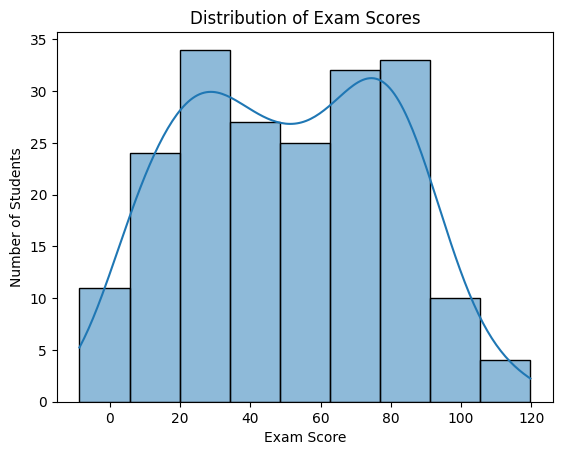

0.03161780954907682
74712.75931229912
76304.76114763669


In [10]:
# Exam Score Distribution, Normal or skewed

# import seaborn as sns
# sns.histplot(df["exam_score"], kde=True)   # KDE = Kernel Density Estimation. It adds a smooth curve on top of your histogram.


# if u want labels
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["exam_score"], kde=True)

plt.xlabel("Exam Score")          # x-axis label
plt.ylabel("Number of Students")  # y-axis label
plt.title("Distribution of Exam Scores")  # plot title

plt.show()

# If both sides match → Normal
# If right side longer → Right skew
# If left side longer → Left skew


# Skewness. Quick Numerical Confirmation (Best Practice).
print(df["exam_score"].skew())  # >0 → right skew, < 0 → left skew, ≈ 0 → normal

# Mean vs Median.  If mean > median: Confirms right skew and viced versa.  Mean vs Median rule is not strict when skew is near 0. Thats why here contradiction is happening, right skewed(>0) but median>mean
print(df["salary"].mean())
print(df["salary"].median())

### Part E — Final Insights

🎯 Insight 1:
Students who study more than 5 hours have a significantly higher probability of passing, showing a strong dependency between effort and performance.

🎯 Insight 2:
Salary distribution is right-skewed, indicating that a small number of employees earn significantly higher salaries than the majority.

🎯 Insight 3:
Employees with more than 5 years of experience have a much higher probability of earning a high salary, making experience a key predictive feature.

🎯 Insight 4 (Bonus):
Salary varies across departments and cities, suggesting structural and regional differences in compensation.

## Final Understanding

### You actually:

- Estimated probabilities
- Discovered dependencies
- Analyzed distributions
- Interpreted skewness
- Extracted insights

That is core data science thinking.